# Custom CNN for Skin Lesion Classification

A PyTorch CNN with custom layers designed for 14-class skin lesion classification.


## 1. Setup and Imports

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from torchinfo import summary
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import seaborn as sns
from tqdm import tqdm
import csv
import copy
import math
import os

# Device configuration
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f'Using device: {device}')

Using device: cuda:0


In [2]:
# ==================== CONFIGURATION ====================
NUM_CLASSES = 14
IMAGE_SIZE = 224
BATCH_SIZE = 32
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-4
NUM_EPOCHS = 100
LR_PATIENCE = 5
LR_FACTOR = 0.5

## 2. Custom Layer Definitions

In [3]:
class SqueezeExcitation(nn.Module):
    """Channel attention mechanism for adaptive feature recalibration."""
    
    def __init__(self, channels, reduction=16):
        """Build the layers."""
        super().__init__()
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Sequential(
            nn.Linear(channels, channels // reduction, bias=False),
            nn.GELU(),
            nn.Linear(channels // reduction, channels, bias=False),
            nn.Sigmoid()
        )
    
    def forward(self, x):
        """Run the forward pass."""
        b, c, _, _ = x.size()
        y = self.avg_pool(x).view(b, c)
        y = self.fc(y).view(b, c, 1, 1)
        return x * y.expand_as(x)

In [4]:
class SkinLesionConvBlock(nn.Module):
    """Depthwise separable convolution with SE attention and dropout."""
    
    def __init__(self, in_channels, out_channels, kernel_size=3, stride=1, dropout=0.1):
        """Build the layers."""
        super().__init__()
        padding = kernel_size // 2
        
        # Depthwise convolution
        self.depthwise = nn.Conv2d(
            in_channels, in_channels, kernel_size=kernel_size,
            stride=stride, padding=padding, groups=in_channels, bias=False
        )
        self.bn1 = nn.BatchNorm2d(in_channels)
        
        # Pointwise convolution
        self.pointwise = nn.Conv2d(in_channels, out_channels, kernel_size=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)
        
        self.activation = nn.GELU()
        self.se = SqueezeExcitation(out_channels)
        self.dropout = nn.Dropout2d(dropout)
    
    def forward(self, x):
        """Run the forward pass."""
        x = self.depthwise(x)
        x = self.bn1(x)
        x = self.activation(x)
        
        x = self.pointwise(x)
        x = self.bn2(x)
        x = self.activation(x)
        
        x = self.se(x)
        x = self.dropout(x)
        return x

In [5]:
class ResidualSkinBlock(nn.Module):
    """Residual block with skip connections for better gradient flow."""
    
    def __init__(self, in_channels, out_channels, dropout=0.1):
        """Build the layers."""
        super().__init__()
        self.conv1 = SkinLesionConvBlock(in_channels, out_channels, dropout=dropout)
        self.conv2 = SkinLesionConvBlock(out_channels, out_channels, dropout=dropout)
        
        # Skip connection with 1x1 conv if dimensions don't match
        self.skip = nn.Identity()
        if in_channels != out_channels:
            self.skip = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=1, bias=False),
                nn.BatchNorm2d(out_channels)
            )
    
    def forward(self, x):
        """Run the forward pass."""
        identity = self.skip(x)
        out = self.conv1(x)
        out = self.conv2(out)
        return out + identity

In [6]:
class MultiScaleFeatureBlock(nn.Module):
    """Parallel convolutions with 3x3, 5x5, 7x7 kernels for multi-scale features."""
    
    def __init__(self, in_channels, out_channels):
        """Build the layers."""
        super().__init__()
        branch_channels = out_channels // 3
        
        self.branch3x3 = nn.Sequential(
            nn.Conv2d(in_channels, branch_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(branch_channels),
            nn.GELU()
        )
        
        self.branch5x5 = nn.Sequential(
            nn.Conv2d(in_channels, branch_channels, kernel_size=5, padding=2, bias=False),
            nn.BatchNorm2d(branch_channels),
            nn.GELU()
        )
        
        self.branch7x7 = nn.Sequential(
            nn.Conv2d(in_channels, branch_channels, kernel_size=7, padding=3, bias=False),
            nn.BatchNorm2d(branch_channels),
            nn.GELU()
        )
        
        # Fusion layer
        concat_channels = branch_channels * 3
        self.fusion = nn.Sequential(
            nn.Conv2d(concat_channels, out_channels, kernel_size=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.GELU()
        )
    
    def forward(self, x):
        """Run the forward pass."""
        b3 = self.branch3x3(x)
        b5 = self.branch5x5(x)
        b7 = self.branch7x7(x)
        concat = torch.cat([b3, b5, b7], dim=1)
        return self.fusion(concat)

In [7]:
class MultiHeadSelfAttention(nn.Module):
    """KAN-inspired multi-head self-attention over feature-map tokens."""
    def __init__(self, embed_dim, num_heads):
        """Build the layers."""
        super().__init__()
        assert embed_dim % num_heads == 0

        self.embed_dim = embed_dim
        self.num_heads = num_heads
        self.head_dim = embed_dim // num_heads

        self.qkv = nn.Linear(embed_dim, embed_dim * 3)
        self.out = nn.Linear(embed_dim, embed_dim)
        self.scale = self.head_dim ** -0.5

    def forward(self, x):
        """Run the forward pass."""
        B, N, C = x.shape

        qkv = self.qkv(x)
        qkv = qkv.reshape(B, N, 3, self.num_heads, self.head_dim)
        qkv = qkv.permute(2, 0, 3, 1, 4)

        q, k, v = qkv[0], qkv[1], qkv[2]

        attn = (q @ k.transpose(-2, -1)) * self.scale
        attn = attn.softmax(dim=-1)

        out = attn @ v
        out = out.transpose(1, 2).reshape(B, N, C)

        return self.out(out)

## 3. Model Creation

In [8]:
class SkinLesionCNN(nn.Module):
    """Custom CNN for Skin Lesion Classification with 14 classes."""
    
    def __init__(self, num_classes=14):
        """Build the layers."""
        super().__init__()
        
        # Initial convolution to expand channels
        self.stem = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.GELU()
        )
        
        # Stage 1: SkinLesionConvBlock (64 filters)
        self.stage1 = SkinLesionConvBlock(64, 64)
        self.pool1 = nn.MaxPool2d(2, 2)
        
        # Stage 2: ResidualSkinBlock (128 filters)
        self.stage2 = ResidualSkinBlock(64, 128)
        self.pool2 = nn.MaxPool2d(2, 2)
        
        # Stage 3: MultiScaleFeatureBlock (256 filters)
        self.stage3 = MultiScaleFeatureBlock(128, 256)
        self.pool3 = nn.MaxPool2d(2, 2)
        
        # Stage 4: SkinLesionConvBlock (512 filters)
        self.stage4 = SkinLesionConvBlock(256, 512)
        
        # Global Average Pooling
        self.gap = nn.AdaptiveAvgPool2d(1)
        
        # Multi-Head Self-Attention (8 heads)
        self.attention = MultiHeadSelfAttention(512, num_heads=8)
        
        # Classification head
        self.classifier = nn.Sequential(
            nn.Linear(512, 256),
            nn.GELU(),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes)
        )
    
    def forward(self, x):
        """Run the forward pass."""
        x = self.stem(x)
        
        x = self.stage1(x)
        x = self.pool1(x)
        
        x = self.stage2(x)
        x = self.pool2(x)
        
        x = self.stage3(x)
        x = self.pool3(x)
        
        x = self.stage4(x)
        
        B, C, H, W = x.shape
        x = x.view(B, C, -1).permute(0, 2, 1) 
        x = self.attention(x)
        x = x.permute(0, 2, 1).view(B, C, H, W)

        x = self.gap(x)
        x = x.view(x.size(0), -1)
        x = self.classifier(x)
        return x

# Create the model
model = SkinLesionCNN(num_classes=NUM_CLASSES)

# Print model summary
summary(model, input_size=(1, 3, IMAGE_SIZE, IMAGE_SIZE))

Layer (type:depth-idx)                        Output Shape              Param #
SkinLesionCNN                                 [1, 14]                   --
├─Sequential: 1-1                             [1, 64, 224, 224]         --
│    └─Conv2d: 2-1                            [1, 64, 224, 224]         1,728
│    └─BatchNorm2d: 2-2                       [1, 64, 224, 224]         128
│    └─GELU: 2-3                              [1, 64, 224, 224]         --
├─SkinLesionConvBlock: 1-2                    [1, 64, 224, 224]         --
│    └─Conv2d: 2-4                            [1, 64, 224, 224]         576
│    └─BatchNorm2d: 2-5                       [1, 64, 224, 224]         128
│    └─GELU: 2-6                              [1, 64, 224, 224]         --
│    └─Conv2d: 2-7                            [1, 64, 224, 224]         4,096
│    └─BatchNorm2d: 2-8                       [1, 64, 224, 224]         128
│    └─GELU: 2-9                              [1, 64, 224, 224]         --
│    └─Squ

## 4. Data Loading and Preprocessing

In [9]:
# Count images per class
from collections import Counter

data_transforms = {
    'train': transforms.Compose([
        transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
        transforms.RandomHorizontalFlip(),
        transforms.RandomVerticalFlip(),
        transforms.RandomRotation(90),
        transforms.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.1),
        transforms.ToTensor(),
        transforms.Normalize(
            [0.485, 0.456, 0.406],
            [0.229, 0.224, 0.225]
        )
    ]),
    'val': transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize(
            [0.485, 0.456, 0.406],
            [0.229, 0.224, 0.225]
        )
    ]),
}

data_dir = '/kaggle/input/skin-ds'

image_datasets = {
    x: datasets.ImageFolder(
        root=os.path.join(data_dir,x),
        transform=data_transforms[x]
    )
    for x in ['train', 'val']
}

dataloaders = {
    x: DataLoader(
        image_datasets[x],
        batch_size=BATCH_SIZE,
        shuffle=True,
        num_workers=4,
        pin_memory=True
    )
    for x in ['train', 'val']
}

dataset_sizes = {x: len(image_datasets[x]) for x in ['train', 'val']}
class_names = image_datasets['train'].classes

print("Classes:", class_names)
print("Number of classes:", len(class_names))
print("Training size:", dataset_sizes['train'])
print("Validation size:", dataset_sizes['val'])

# For training set
train_labels = [label for _, label in image_datasets['train'].samples]
train_counts = Counter(train_labels)

# For validation set
val_labels = [label for _, label in image_datasets['val'].samples]
val_counts = Counter(val_labels)

# Print nicely
print("=" * 60)
print(f"{'Class':<35} {'Train':>10} {'Val':>10}")
print("=" * 60)

for idx, class_name in enumerate(class_names):
    print(f"{class_name:<35} {train_counts[idx]:>10} {val_counts[idx]:>10}")

print("=" * 60)
print(f"{'TOTAL':<35} {len(image_datasets['train']):>10} {len(image_datasets['val']):>10}")

Classes: ['Actinic keratoses', 'Basal cell carcinoma', 'Benign keratosis-like lesions', 'Chickenpox', 'Cowpox', 'Dermatofibroma', 'HFMD', 'Healthy', 'Measles', 'Melanocytic nevi', 'Melanoma', 'Monkeypox', 'Squamous cell carcinoma', 'Vascular lesions']
Number of classes: 14
Training size: 29322
Validation size: 3660
Class                                    Train        Val
Actinic keratoses                          693         86
Basal cell carcinoma                      2658        332
Benign keratosis-like lesions             2099        262
Chickenpox                                 900        112
Cowpox                                     792         99
Dermatofibroma                             191         23
HFMD                                      1932        241
Healthy                                   1368        171
Measles                                    660         82
Melanocytic nevi                         10300       1287
Melanoma                                  361

## 5. Training the Model

In [10]:
model = model.to(device)

#custom loss
class FocalLoss(nn.Module):
    """Focal loss to down-weight easy examples under class imbalance."""
    def __init__(self, alpha=1, gamma=2, reduction='mean'):
        """Build the layers."""
        super(FocalLoss, self).__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction

    def forward(self, inputs, targets):
        """Run the forward pass."""
        ce_loss = F.cross_entropy(inputs, targets, reduction='none')
        pt = torch.exp(-ce_loss) # probability of the correct class
        focal_loss = self.alpha * (1 - pt) ** self.gamma * ce_loss
        
        if self.reduction == 'mean':
            return focal_loss.mean()
        else:
            return focal_loss.sum()

# Usage
criterion = FocalLoss(gamma=2.0)
optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=LR_FACTOR, patience=LR_PATIENCE)

# Checkpoint directory
CHECKPOINT_DIR = '/kaggle/working/checkpoints'
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

def train_model(model, criterion, optimizer, num_epochs, scheduler=None, reset_log=True, start_epoch=0, best_acc=0.0):
    """Train the model, log per-epoch metrics, and keep the best checkpoint."""
    best_model_wts = copy.deepcopy(model.state_dict())
    best_loss = float('inf')
    early_stop_counter = 0
    
    csv_file = 'training_history.csv'
    header = ['epoch', 'train_loss', 'train_acc', 'val_loss', 'val_acc', 'learning_rates']
    
    # LOGGING SETUP
    mode = 'w' if reset_log else 'a'
    should_write_header = reset_log or not os.path.exists(csv_file)
    
    if should_write_header:
        with open(csv_file, 'w', newline='') as f:
            writer = csv.writer(f)
            writer.writerow(header)
        print(f"Created new training log: {csv_file}")
    else:
        print(f"Appending to existing training log: {csv_file}")

    for epoch in range(start_epoch, num_epochs):
        print(f"Epoch {epoch}/{num_epochs - 1}")
        print("-" * 10)
        
        metrics = {}

        for phase in ['train', 'val']:
            model.train() if phase == 'train' else model.eval()

            running_loss = 0.0
            running_corrects = 0
            loss_nans = 0

            for inputs, labels in tqdm(dataloaders[phase]):
                inputs = inputs.to(device)
                labels = labels.to(device)

                optimizer.zero_grad()

                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    loss = criterion(outputs, labels)

                    if torch.isnan(loss):
                        loss_nans += 1
                        continue
                        
                    _, preds = torch.max(outputs, 1)

                    if phase == 'train':
                        loss.backward()
                        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                        optimizer.step()
                
                loss_val = loss.item()
                if not math.isnan(loss_val):
                    running_loss += loss_val * inputs.size(0)
                    running_corrects += (preds == labels).sum().item()

            epoch_loss = running_loss / dataset_sizes[phase]
            epoch_acc = running_corrects / dataset_sizes[phase]
            metrics[phase] = (epoch_loss, epoch_acc)

            print(f"{phase} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}")
            if loss_nans > 0:
                print(f"Warning: {loss_nans} batches skipped due to NaN loss in {phase}")

            if phase == 'val':
                # Update scheduler
                if scheduler is not None:
                    scheduler.step(epoch_loss)
                
                # Early stopping check
                if epoch_acc > best_acc:
                    best_acc = epoch_acc
                    best_loss = epoch_loss
                    best_model_wts = copy.deepcopy(model.state_dict())
                    early_stop_counter = 0
                else:
                    early_stop_counter += 1
        
        current_lrs = [group['lr'] for group in optimizer.param_groups]
        
        with open(csv_file, 'a', newline='') as f:
            writer = csv.writer(f)
            writer.writerow([
                epoch, 
                metrics['train'][0], metrics['train'][1], 
                metrics['val'][0], metrics['val'][1],
                str(current_lrs)
            ])
                
        print(f"Current Learning Rates: {current_lrs}")
        
        # Save checkpoint every 25 epochs
        if (epoch + 1) % 25 == 0:
            checkpoint_path = os.path.join(CHECKPOINT_DIR, f'checkpoint_epoch_{epoch + 1}.pth')
            torch.save({
                'epoch': epoch + 1,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'scheduler_state_dict': scheduler.state_dict() if scheduler else None,
                'best_acc': best_acc,
                'best_model_wts': best_model_wts,
                'early_stop_counter': early_stop_counter
            }, checkpoint_path)
            print(f"Checkpoint saved: {checkpoint_path}")
        

    print(f"Best val Acc: {best_acc:.4f}")
    model.load_state_dict(best_model_wts)
    return model

# Start Training
model_ft = train_model(model, criterion, optimizer, NUM_EPOCHS, scheduler=scheduler, reset_log=True)

# Save the model
torch.save(model_ft.state_dict(), 'custom_cnn_skin_lesion_100_epochs.pth')
print('Model saved')

Created new training log: training_history.csv
Epoch 0/99
----------


100%|██████████| 917/917 [05:00<00:00,  3.05it/s]


train Loss: 1.0528 Acc: 0.4752


100%|██████████| 115/115 [00:22<00:00,  5.10it/s]


val Loss: 0.7737 Acc: 0.5495
Current Learning Rates: [0.001]
Epoch 1/99
----------


...

val Loss: 0.2401 Acc: 0.8626
Current Learning Rates: [7.8125e-06]
Epoch 99/99
----------


100%|██████████| 917/917 [04:59<00:00,  3.07it/s]


train Loss: 0.0768 Acc: 0.9155


100%|██████████| 115/115 [00:17<00:00,  6.44it/s]

val Loss: 0.2423 Acc: 0.8634
Current Learning Rates: [7.8125e-06]
Checkpoint saved: /kaggle/working/checkpoints/checkpoint_epoch_100.pth
Best val Acc: 0.8672
Model saved


## 7. Resume Training from Checkpoint (Optional)

Run this cell ONLY if training crashed and you want to resume from the latest checkpoint.

In [14]:
# === RESUME TRAINING FROM CHECKPOINT ===
# Run this cell ONLY if training crashed and you want to resume from the latest checkpoint

import os
import glob
import pandas as pd

def find_latest_checkpoint(checkpoint_dir='/kaggle/input/checkpoints'):
    """Find the latest checkpoint file based on epoch number."""
    checkpoints = glob.glob(os.path.join(checkpoint_dir, 'checkpoint_epoch_*.pth'))
    if not checkpoints:
        return None
    
    # Extract epoch numbers and find max
    latest = max(checkpoints, key=lambda x: int(x.split('_epoch_')[1].split('.pth')[0]))
    return latest

def trim_csv_to_epoch(csv_file, last_epoch):
    """Trim CSV file to only include epochs up to last_epoch (exclusive).
    This ensures we don't have duplicate entries when resuming."""
    if not os.path.exists(csv_file):
        return
    
    df = pd.read_csv(csv_file)
    # Keep only epochs before the resume point
    df = df[df['epoch'] < last_epoch]
    df.to_csv(csv_file, index=False)
    print(f"Trimmed {csv_file} to epoch {last_epoch - 1} (removed epochs >= {last_epoch})")

def resume_training_from_checkpoint(checkpoint_path, target_epochs=100):
    """Resume training from a checkpoint."""
    print(f"Loading checkpoint: {checkpoint_path}")
    checkpoint = torch.load(checkpoint_path, map_location=device)
    
    # Recreate model, optimizer, scheduler
    resume_model = SkinLesionCNN(num_classes=NUM_CLASSES).to(device)
    resume_model.load_state_dict(checkpoint['model_state_dict'])
    
    resume_optimizer = optim.AdamW(resume_model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
    resume_optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    
    resume_scheduler = optim.lr_scheduler.ReduceLROnPlateau(resume_optimizer, mode='min', factor=LR_FACTOR, patience=LR_PATIENCE)
    if checkpoint['scheduler_state_dict']:
        resume_scheduler.load_state_dict(checkpoint['scheduler_state_dict'])
    
    start_epoch = checkpoint['epoch']
    best_acc = checkpoint['best_acc']
    
    print(f"Resuming from epoch {start_epoch} with best_acc={best_acc:.4f}")
    print(f"Training will continue to epoch {target_epochs}")
    
    # Trim CSV to remove any partial epochs after the checkpoint
    trim_csv_to_epoch('/kaggle/input/training_history.csv', start_epoch)
    
    # Resume training with reset_log=False to append to existing CSV
    resumed_model = train_model(resume_model, criterion, resume_optimizer, target_epochs,scheduler=resume_scheduler, reset_log=False,start_epoch=start_epoch,best_acc=best_acc)
    
    return resumed_model

# Find and load the latest checkpoint
latest_ckpt = find_latest_checkpoint()
if latest_ckpt:
    print(f"Found latest checkpoint: {latest_ckpt}")
    model_ft = resume_training_from_checkpoint(latest_ckpt, target_epochs=100)
    torch.save(model_ft.state_dict(), 'custom_cnn_skin_lesion_100_epochs.pth')
    print('Resumed model saved!')
else:
    print("No checkpoint found. Please ensure training was run with checkpoint saving enabled.")

No checkpoint found. Please ensure training was run with checkpoint saving enabled.


## 6. Evaluation & Visualization

In [15]:
# Load model

import torch
import torch.nn.functional as F
from tqdm import tqdm
from sklearn.metrics import accuracy_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import os

# Load Model
# Model config: SkinLesionCNN(num_classes=14)
checkpoint_path = '/kaggle/input/custom-cnn-v2/pytorch/default/1/v2_custom_cnn_skin_lesion_100_epochs.pth'

print(f"Loading model from {checkpoint_path}...")
eval_model = SkinLesionCNN(num_classes=NUM_CLASSES)
checkpoint = torch.load(checkpoint_path, map_location=device)
if isinstance(checkpoint, dict) and 'model_state_dict' in checkpoint:
    eval_model.load_state_dict(checkpoint['model_state_dict'])
else:
    eval_model.load_state_dict(checkpoint)
eval_model = eval_model.to(device)
print("Model loaded successfully!")

Loading model from /kaggle/input/custom-cnn-v2/pytorch/default/1/v2_custom_cnn_skin_lesion_100_epochs.pth...
Model loaded successfully!


ROC-AUC Curve Analysis
Computing predictions for ROC-AUC...


100%|██████████| 115/115 [00:17<00:00,  6.40it/s]



AUC Scores by Class:
  Actinic keratoses                  : 0.9762
  Basal cell carcinoma               : 0.9883
  Benign keratosis-like lesions      : 0.9667
  Chickenpox                         : 0.9999
  Cowpox                             : 0.9993
  Dermatofibroma                     : 0.9814
  HFMD                               : 0.9995
  Healthy                            : 0.9999
  Measles                            : 1.0000
  Melanocytic nevi                   : 0.9740
  Melanoma                           : 0.9481
  Monkeypox                          : 0.9996
  Squamous cell carcinoma            : 0.9754
  Vascular lesions                   : 1.0000
--------------------------------------------------
  Micro-average                      : 0.9934
  Macro-average                      : 0.9863


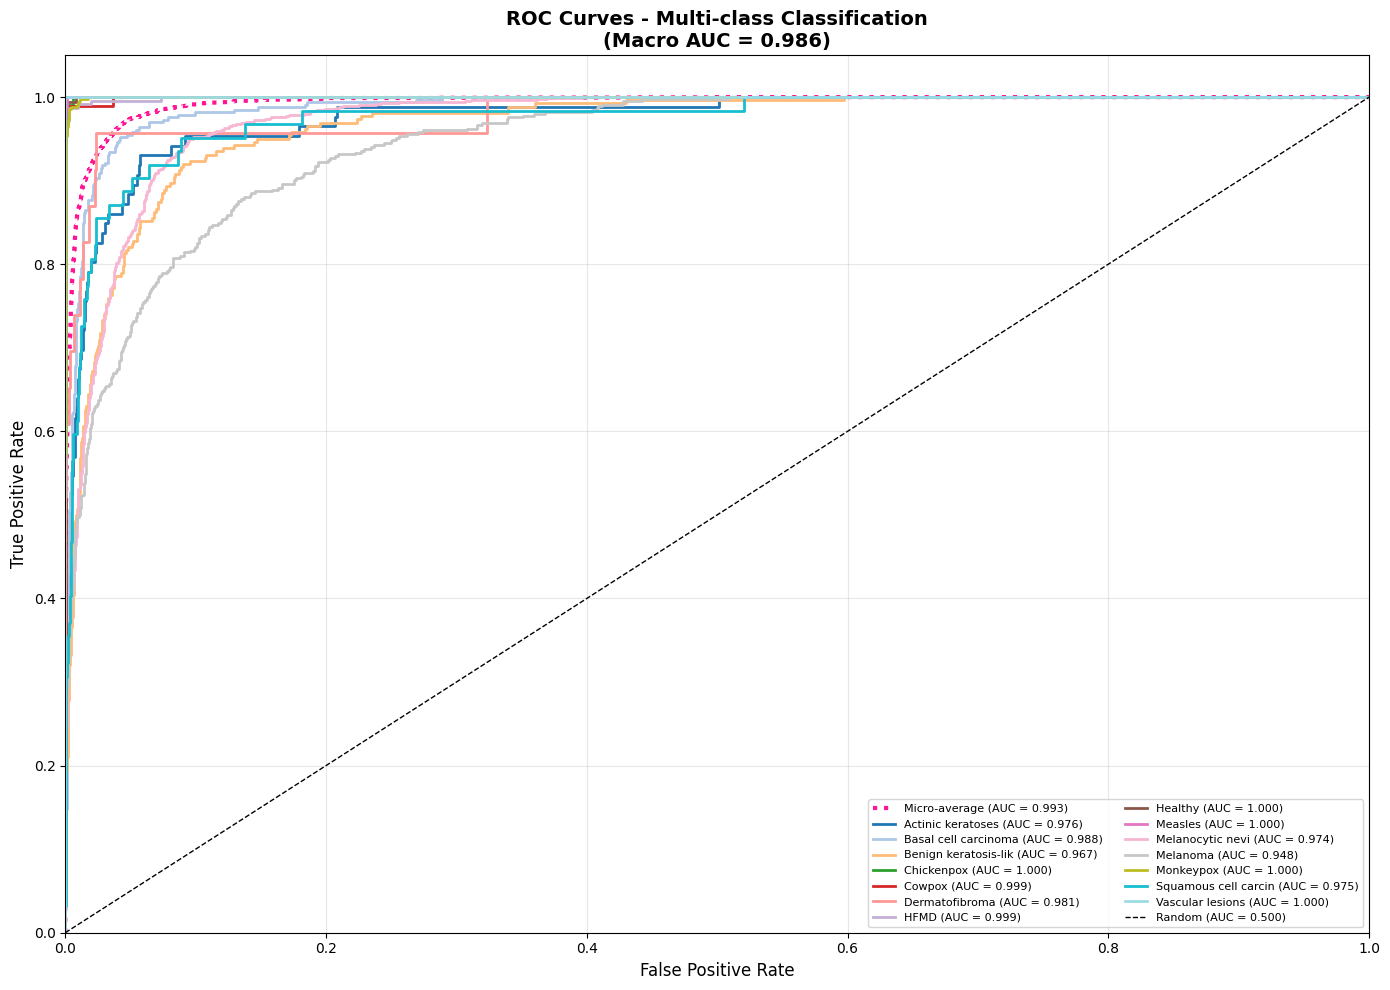


Saved to 'roc_auc_curves.png'


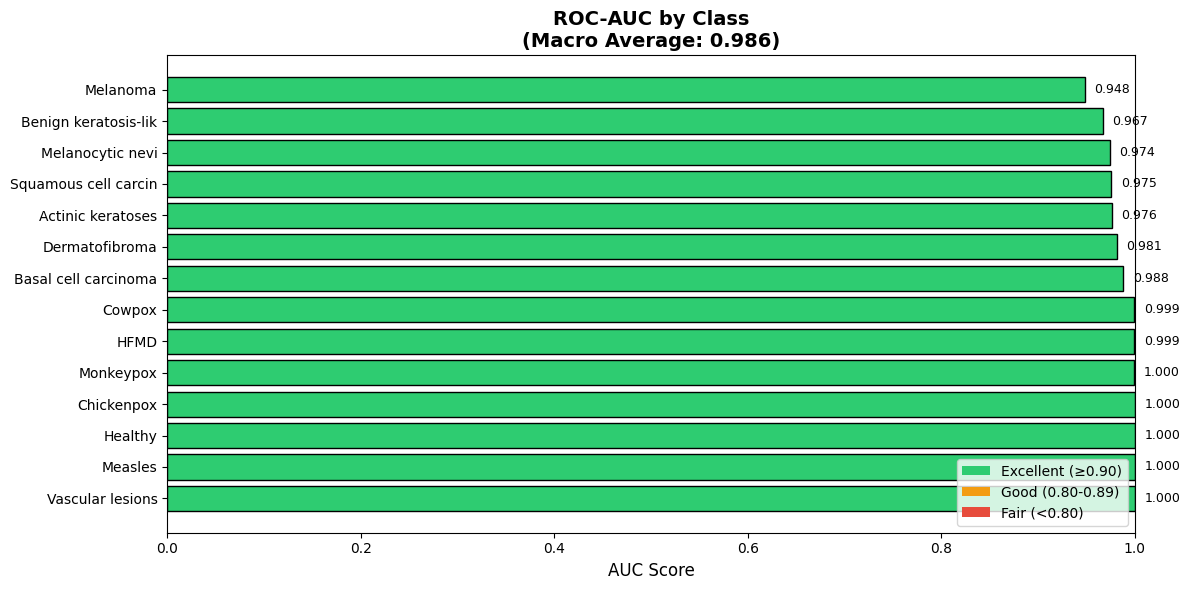


Saved to 'roc_auc_summary.png'


In [13]:
# === ROC-AUC Curve Generation ===
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc, roc_auc_score
from sklearn.preprocessing import label_binarize
from tqdm import tqdm
from itertools import cycle

def compute_roc_auc(model, dataloader, class_names, device):
    """
    Compute ROC-AUC for multi-class classification.
    
    Returns:
        all_labels: True labels
        all_probs: Predicted probabilities for each class
        fpr: False positive rates (dict per class)
        tpr: True positive rates (dict per class)
        roc_auc: AUC scores (dict per class)
    """
    model.eval()
    all_labels = []
    all_probs = []
    
    print("Computing predictions for ROC-AUC...")
    with torch.no_grad():
        for inputs, labels in tqdm(dataloader):
            inputs = inputs.to(device)
            outputs = model(inputs)
            probs = F.softmax(outputs, dim=1)
            
            all_labels.extend(labels.numpy())
            all_probs.extend(probs.cpu().numpy())
    
    all_labels = np.array(all_labels)
    all_probs = np.array(all_probs)
    
    n_classes = len(class_names)
    
    # Binarize labels for multi-class ROC
    labels_bin = label_binarize(all_labels, classes=list(range(n_classes)))
    
    # Compute ROC curve and AUC for each class
    fpr = {}
    tpr = {}
    roc_auc = {}
    
    for i in range(n_classes):
        fpr[i], tpr[i], _ = roc_curve(labels_bin[:, i], all_probs[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])
    
    # Compute micro-average ROC curve
    fpr["micro"], tpr["micro"], _ = roc_curve(labels_bin.ravel(), all_probs.ravel())
    roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])
    
    # Compute macro-average AUC
    roc_auc["macro"] = np.mean([roc_auc[i] for i in range(n_classes)])
    
    return all_labels, all_probs, fpr, tpr, roc_auc


def plot_roc_curves(fpr, tpr, roc_auc, class_names, figsize=(14, 10)):
    """
    Plot ROC curves for all classes.
    """
    n_classes = len(class_names)
    
    # Colors for each class
    colors = plt.cm.tab20(np.linspace(0, 1, n_classes))
    
    plt.figure(figsize=figsize)
    
    # Plot micro-average ROC curve
    plt.plot(
        fpr["micro"], tpr["micro"],
        label=f'Micro-average (AUC = {roc_auc["micro"]:.3f})',
        color='deeppink', linestyle=':', linewidth=3
    )
    
    # Plot each class
    for i, (class_name, color) in enumerate(zip(class_names, colors)):
        plt.plot(
            fpr[i], tpr[i], color=color, lw=2,
            label=f'{class_name[:20]} (AUC = {roc_auc[i]:.3f})'
        )
    
    # Diagonal line (random classifier)
    plt.plot([0, 1], [0, 1], 'k--', lw=1, label='Random (AUC = 0.500)')
    
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate', fontsize=12)
    plt.ylabel('True Positive Rate', fontsize=12)
    plt.title(f'ROC Curves - Multi-class Classification\n(Macro AUC = {roc_auc["macro"]:.3f})', 
              fontsize=14, fontweight='bold')
    plt.legend(loc='lower right', fontsize=8, ncol=2)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('roc_auc_curves.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    print(f"\nSaved to 'roc_auc_curves.png'")
    return


def plot_roc_summary(roc_auc, class_names, figsize=(12, 6)):
    """
    Plot a bar chart showing AUC scores for each class.
    """
    n_classes = len(class_names)
    aucs = [roc_auc[i] for i in range(n_classes)]
    
    # Sort by AUC
    sorted_indices = np.argsort(aucs)[::-1]
    sorted_names = [class_names[i][:20] for i in sorted_indices]
    sorted_aucs = [aucs[i] for i in sorted_indices]
    
    # Colors based on AUC
    colors = ['#2ecc71' if a >= 0.9 else '#f39c12' if a >= 0.8 else '#e74c3c' for a in sorted_aucs]
    
    plt.figure(figsize=figsize)
    bars = plt.barh(range(n_classes), sorted_aucs, color=colors, edgecolor='black')
    plt.yticks(range(n_classes), sorted_names, fontsize=10)
    plt.xlabel('AUC Score', fontsize=12)
    plt.title(f'ROC-AUC by Class\n(Macro Average: {roc_auc["macro"]:.3f})', fontsize=14, fontweight='bold')
    plt.xlim([0, 1])
    
    # Add value labels
    for i, (bar, auc_val) in enumerate(zip(bars, sorted_aucs)):
        plt.text(auc_val + 0.01, i, f'{auc_val:.3f}', va='center', fontsize=9)
    
    # Add legend
    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor='#2ecc71', label='Excellent (≥0.90)'),
        Patch(facecolor='#f39c12', label='Good (0.80-0.89)'),
        Patch(facecolor='#e74c3c', label='Fair (<0.80)')
    ]
    plt.legend(handles=legend_elements, loc='lower right')
    
    plt.tight_layout()
    plt.savefig('roc_auc_summary.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    print(f"\nSaved to 'roc_auc_summary.png'")


# === RUN ===
print("="*60)
print("ROC-AUC Curve Analysis")
print("="*60)

# Compute ROC-AUC
all_labels, all_probs, fpr, tpr, roc_auc = compute_roc_auc(
    eval_model, dataloaders['val'], class_names, device
)

# Print AUC scores
print("\n" + "="*50)
print("AUC Scores by Class:")
print("="*50)
for i, name in enumerate(class_names):
    print(f"  {name:35s}: {roc_auc[i]:.4f}")
print("-"*50)
print(f"  {'Micro-average':35s}: {roc_auc['micro']:.4f}")
print(f"  {'Macro-average':35s}: {roc_auc['macro']:.4f}")
print("="*50)

# Plot ROC curves
plot_roc_curves(fpr, tpr, roc_auc, class_names)

# Plot summary bar chart
plot_roc_summary(roc_auc, class_names)

Precision-Recall Curve Analysis
Computing predictions for PR curves...


100%|██████████| 115/115 [00:17<00:00,  6.42it/s]



Average Precision (AP) Scores by Class:
  Actinic keratoses                  : 0.6760
  Basal cell carcinoma               : 0.8971
  Benign keratosis-like lesions      : 0.7523
  Chickenpox                         : 0.9978
  Cowpox                             : 0.9769
  Dermatofibroma                     : 0.7169
  HFMD                               : 0.9949
  Healthy                            : 0.9987
  Measles                            : 0.9987
  Melanocytic nevi                   : 0.9486
  Melanoma                           : 0.7899
  Monkeypox                          : 0.9970
  Squamous cell carcinoma            : 0.6115
  Vascular lesions                   : 1.0000
--------------------------------------------------
  Micro-average                      : 0.9374
  Macro-average                      : 0.8826


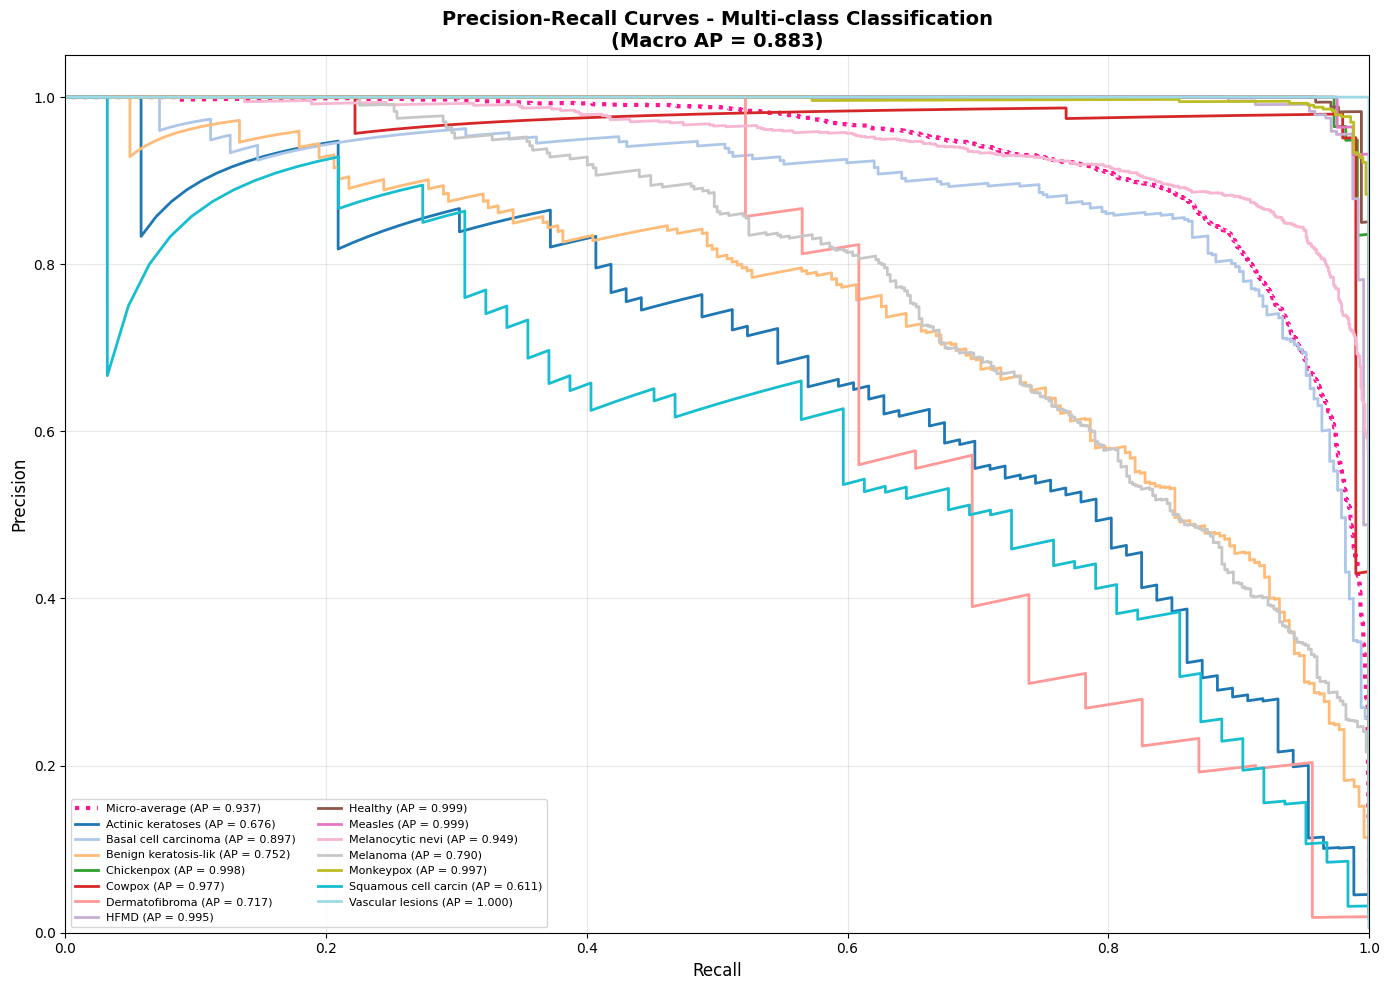


Saved to 'precision_recall_curves.png'


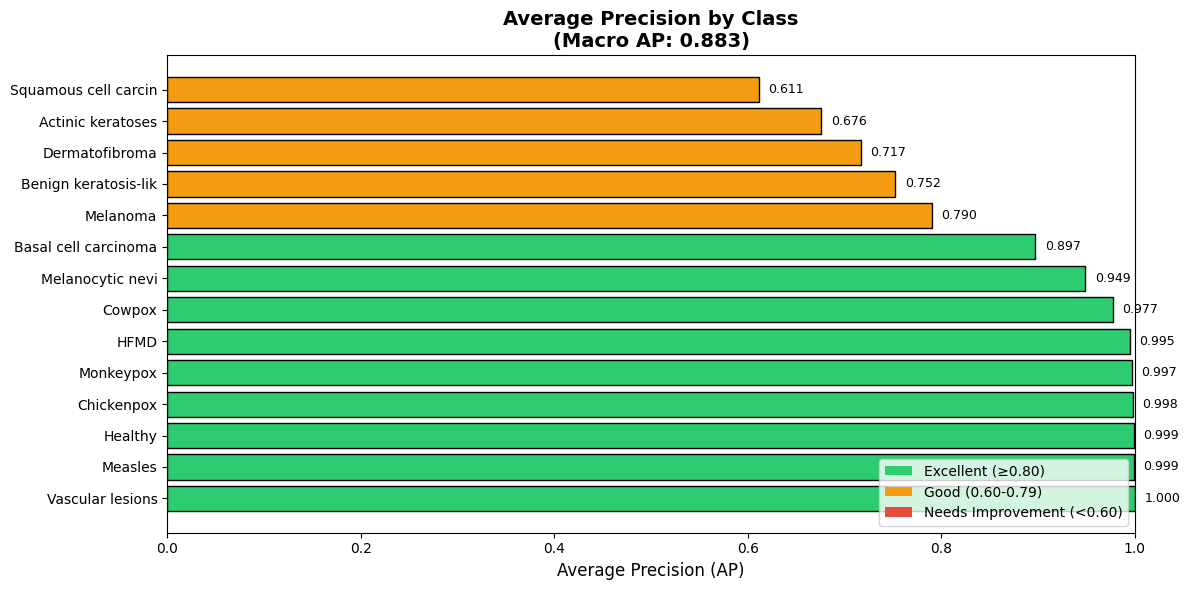


Saved to 'average_precision_summary.png'

Note: Run ROC-AUC cell first to generate combined metrics plot.


In [12]:
# === Precision-Recall Curve Generation ===
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, average_precision_score
from sklearn.preprocessing import label_binarize
from tqdm import tqdm

def compute_pr_curves(model, dataloader, class_names, device):
    """
    Compute Precision-Recall curves for multi-class classification.
    
    Returns:
        all_labels: True labels
        all_probs: Predicted probabilities for each class
        precision: Precision values (dict per class)
        recall: Recall values (dict per class)
        avg_precision: Average precision scores (dict per class)
    """
    model.eval()
    all_labels = []
    all_probs = []
    
    print("Computing predictions for PR curves...")
    with torch.no_grad():
        for inputs, labels in tqdm(dataloader):
            inputs = inputs.to(device)
            outputs = model(inputs)
            probs = F.softmax(outputs, dim=1)
            
            all_labels.extend(labels.numpy())
            all_probs.extend(probs.cpu().numpy())
    
    all_labels = np.array(all_labels)
    all_probs = np.array(all_probs)
    
    n_classes = len(class_names)
    
    # Binarize labels for multi-class PR
    labels_bin = label_binarize(all_labels, classes=list(range(n_classes)))
    
    # Compute PR curve and Average Precision for each class
    precision = {}
    recall = {}
    avg_precision = {}
    
    for i in range(n_classes):
        precision[i], recall[i], _ = precision_recall_curve(labels_bin[:, i], all_probs[:, i])
        avg_precision[i] = average_precision_score(labels_bin[:, i], all_probs[:, i])
    
    # Compute micro-average PR curve
    precision["micro"], recall["micro"], _ = precision_recall_curve(
        labels_bin.ravel(), all_probs.ravel()
    )
    avg_precision["micro"] = average_precision_score(labels_bin, all_probs, average="micro")
    
    # Compute macro-average AP
    avg_precision["macro"] = np.mean([avg_precision[i] for i in range(n_classes)])
    
    return all_labels, all_probs, precision, recall, avg_precision


def plot_pr_curves(precision, recall, avg_precision, class_names, figsize=(14, 10)):
    """
    Plot Precision-Recall curves for all classes.
    """
    n_classes = len(class_names)
    
    # Colors for each class
    colors = plt.cm.tab20(np.linspace(0, 1, n_classes))
    
    plt.figure(figsize=figsize)
    
    # Plot micro-average PR curve
    plt.plot(
        recall["micro"], precision["micro"],
        label=f'Micro-average (AP = {avg_precision["micro"]:.3f})',
        color='deeppink', linestyle=':', linewidth=3
    )
    
    # Plot each class
    for i, (class_name, color) in enumerate(zip(class_names, colors)):
        plt.plot(
            recall[i], precision[i], color=color, lw=2,
            label=f'{class_name[:20]} (AP = {avg_precision[i]:.3f})'
        )
    
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('Recall', fontsize=12)
    plt.ylabel('Precision', fontsize=12)
    plt.title(f'Precision-Recall Curves - Multi-class Classification\n(Macro AP = {avg_precision["macro"]:.3f})', 
              fontsize=14, fontweight='bold')
    plt.legend(loc='lower left', fontsize=8, ncol=2)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('precision_recall_curves.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    print(f"\nSaved to 'precision_recall_curves.png'")
    return


def plot_ap_summary(avg_precision, class_names, figsize=(12, 6)):
    """
    Plot a bar chart showing Average Precision scores for each class.
    """
    n_classes = len(class_names)
    aps = [avg_precision[i] for i in range(n_classes)]
    
    # Sort by AP
    sorted_indices = np.argsort(aps)[::-1]
    sorted_names = [class_names[i][:20] for i in sorted_indices]
    sorted_aps = [aps[i] for i in sorted_indices]
    
    # Colors based on AP
    colors = ['#2ecc71' if a >= 0.8 else '#f39c12' if a >= 0.6 else '#e74c3c' for a in sorted_aps]
    
    plt.figure(figsize=figsize)
    bars = plt.barh(range(n_classes), sorted_aps, color=colors, edgecolor='black')
    plt.yticks(range(n_classes), sorted_names, fontsize=10)
    plt.xlabel('Average Precision (AP)', fontsize=12)
    plt.title(f'Average Precision by Class\n(Macro AP: {avg_precision["macro"]:.3f})', fontsize=14, fontweight='bold')
    plt.xlim([0, 1])
    
    # Add value labels
    for i, (bar, ap_val) in enumerate(zip(bars, sorted_aps)):
        plt.text(ap_val + 0.01, i, f'{ap_val:.3f}', va='center', fontsize=9)
    
    # Add legend
    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor='#2ecc71', label='Excellent (≥0.80)'),
        Patch(facecolor='#f39c12', label='Good (0.60-0.79)'),
        Patch(facecolor='#e74c3c', label='Needs Improvement (<0.60)')
    ]
    plt.legend(handles=legend_elements, loc='lower right')
    
    plt.tight_layout()
    plt.savefig('average_precision_summary.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    print(f"\nSaved to 'average_precision_summary.png'")


def plot_combined_metrics(roc_auc, avg_precision, class_names, figsize=(14, 8)):
    """
    Plot combined ROC-AUC and Average Precision comparison.
    """
    n_classes = len(class_names)
    
    x = np.arange(n_classes)
    width = 0.35
    
    aucs = [roc_auc[i] for i in range(n_classes)]
    aps = [avg_precision[i] for i in range(n_classes)]
    
    # Sort by AUC
    sorted_indices = np.argsort(aucs)[::-1]
    sorted_names = [class_names[i][:18] for i in sorted_indices]
    sorted_aucs = [aucs[i] for i in sorted_indices]
    sorted_aps = [aps[i] for i in sorted_indices]
    
    fig, ax = plt.subplots(figsize=figsize)
    
    bars1 = ax.barh(x - width/2, sorted_aucs, width, label='ROC-AUC', color='#3498db', edgecolor='black')
    bars2 = ax.barh(x + width/2, sorted_aps, width, label='Avg Precision', color='#e74c3c', edgecolor='black')
    
    ax.set_xlabel('Score', fontsize=12)
    ax.set_title('ROC-AUC vs Average Precision by Class', fontsize=14, fontweight='bold')
    ax.set_yticks(x)
    ax.set_yticklabels(sorted_names, fontsize=9)
    ax.set_xlim([0, 1.1])
    ax.legend(loc='lower right')
    ax.grid(True, alpha=0.3, axis='x')
    
    # Add value labels
    for bar, val in zip(bars1, sorted_aucs):
        ax.text(val + 0.01, bar.get_y() + bar.get_height()/2, f'{val:.2f}', va='center', fontsize=7)
    for bar, val in zip(bars2, sorted_aps):
        ax.text(val + 0.01, bar.get_y() + bar.get_height()/2, f'{val:.2f}', va='center', fontsize=7)
    
    plt.tight_layout()
    plt.savefig('combined_metrics.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    print(f"\nSaved to 'combined_metrics.png'")


# === RUN ===
print("="*60)
print("Precision-Recall Curve Analysis")
print("="*60)

# Compute PR curves
all_labels, all_probs, precision, recall, avg_precision = compute_pr_curves(
    eval_model, dataloaders['val'], class_names, device
)

# Print AP scores
print("\n" + "="*50)
print("Average Precision (AP) Scores by Class:")
print("="*50)
for i, name in enumerate(class_names):
    print(f"  {name:35s}: {avg_precision[i]:.4f}")
print("-"*50)
print(f"  {'Micro-average':35s}: {avg_precision['micro']:.4f}")
print(f"  {'Macro-average':35s}: {avg_precision['macro']:.4f}")
print("="*50)

# Plot PR curves
plot_pr_curves(precision, recall, avg_precision, class_names)

# Plot AP summary bar chart
plot_ap_summary(avg_precision, class_names)

# If you have roc_auc from previous cell, plot combined comparison
try:
    plot_combined_metrics(roc_auc, avg_precision, class_names)
except NameError:
    print("\nNote: Run ROC-AUC cell first to generate combined metrics plot.")

FULL PERFORMANCE METRICS REPORT (with TTA)
Computing predictions with TTA (Original + HFlip + VFlip)...


100%|██████████| 115/115 [00:29<00:00,  3.92it/s]



OVERALL PERFORMANCE METRICS (with TTA)

Metric                                Value
---------------------------------------------
Accuracy (TTA)                       0.8770
Balanced Accuracy (TTA)              0.8526
Top-3 Accuracy (TTA)                 0.9880
Top-5 Accuracy (TTA)                 0.9975
Cohen Kappa                          0.8499
Matthews Corr. Coef.                 0.8504
---------------------------------------------
Precision (Macro)                    0.8643
Precision (Micro)                    0.8770
Precision (Weighted)                 0.8747
---------------------------------------------
Recall (Macro)                       0.8526
Recall (Micro)                       0.8770
Recall (Weighted)                    0.8770
---------------------------------------------
F1-Score (Macro)                     0.8572
F1-Score (Micro)                     0.8770
F1-Score (Weighted)                  0.8745

PER-CLASS PERFORMANCE METRICS (with TTA)

Class                       

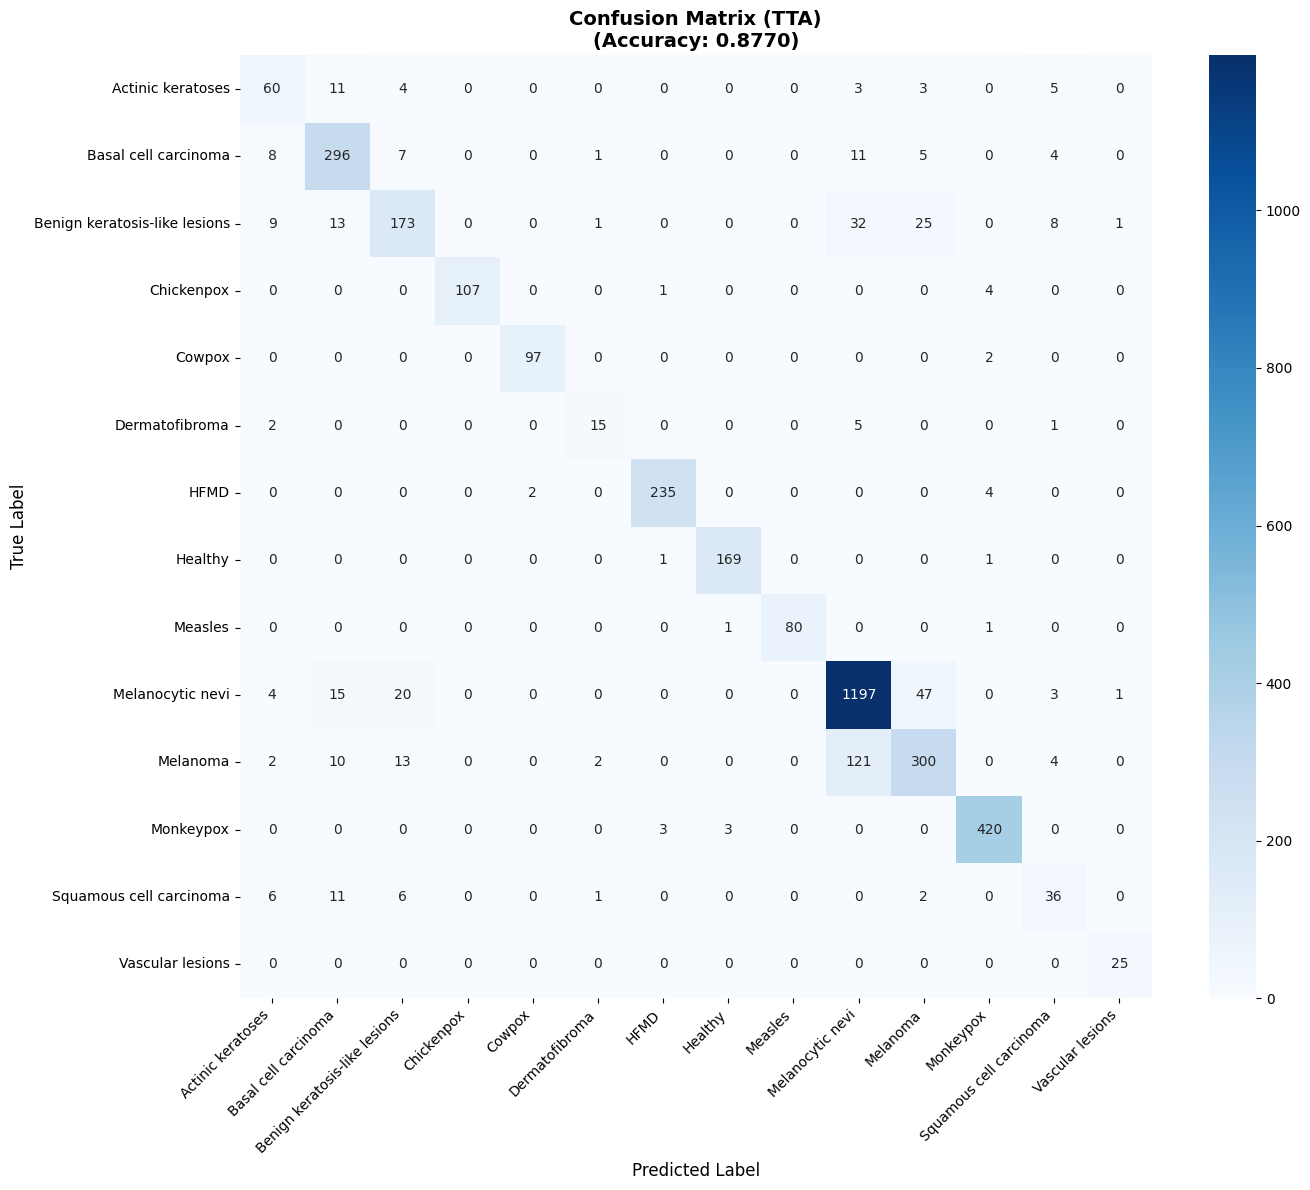


Saved confusion matrix to 'confusion_matrix_tta.png'


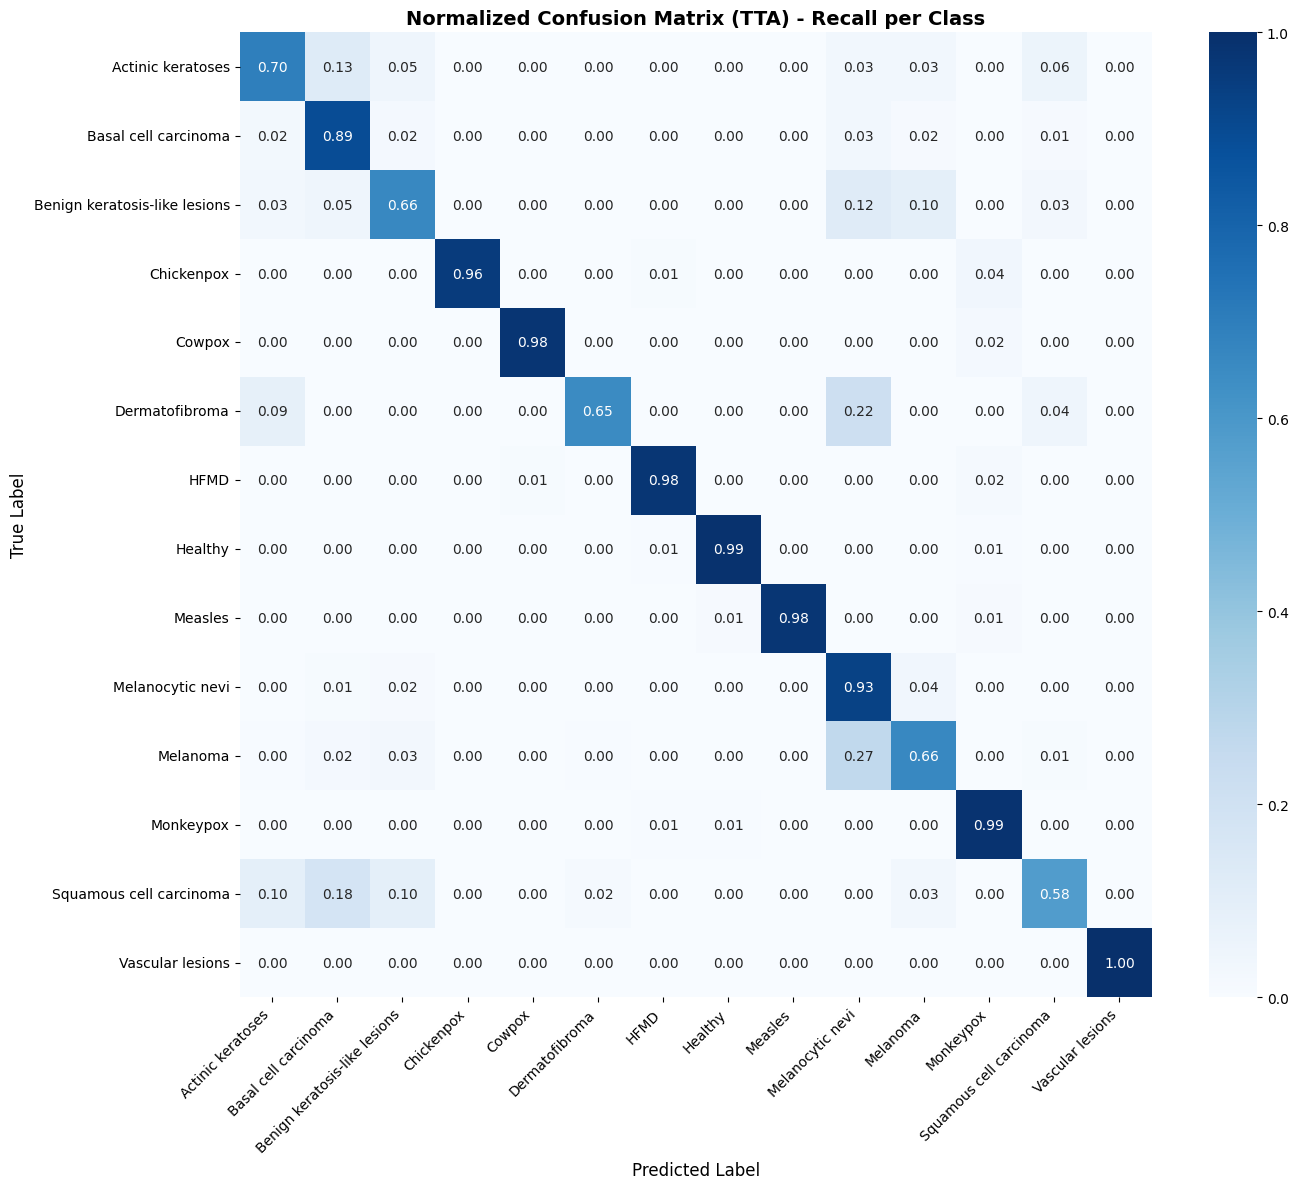

Saved normalized confusion matrix to 'confusion_matrix_normalized_tta.png'


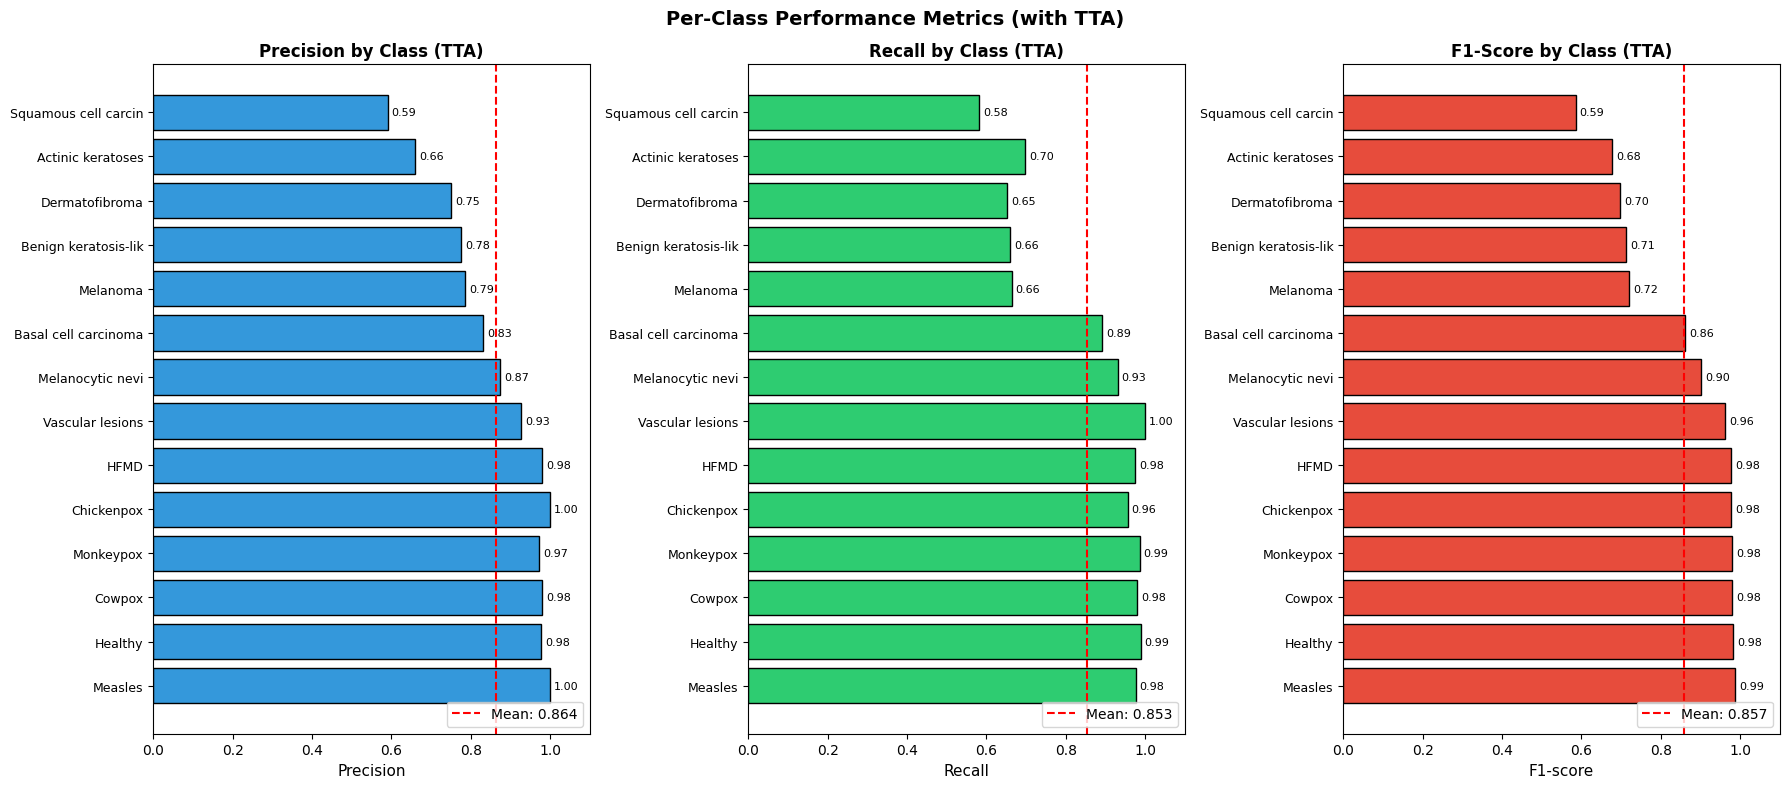

Saved metrics chart to 'metrics_by_class_tta.png'

Saved summary to 'performance_summary_tta.csv'
Saved per-class metrics to 'per_class_metrics_tta.csv'

REPORT COMPLETE!

Generated files:
  - confusion_matrix_tta.png
  - confusion_matrix_normalized_tta.png
  - metrics_by_class_tta.png
  - performance_summary_tta.csv
  - per_class_metrics_tta.csv


In [11]:
# === Full Performance Metrics Report with TTA ===
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score,
    precision_score, recall_score, f1_score,
    balanced_accuracy_score, cohen_kappa_score, matthews_corrcoef,
    top_k_accuracy_score
)
from tqdm import tqdm
import pandas as pd

def get_predictions_with_tta(model, dataloader, device):
    """
    Get all predictions and labels using Test Time Augmentation (TTA).
    
    TTA Strategy:
    1. Original image
    2. Horizontal flip
    3. Vertical flip
    
    Final prediction = average of softmax probabilities from all augmentations
    """
    model.eval()
    all_labels = []
    all_preds = []
    all_probs = []
    
    print("Computing predictions with TTA (Original + HFlip + VFlip)...")
    with torch.no_grad():
        for inputs, labels in tqdm(dataloader):
            inputs = inputs.to(device)
            
            # 1. Original prediction
            outputs_orig = model(inputs)
            probs_orig = F.softmax(outputs_orig, dim=1)
            
            # 2. Horizontal flip
            inputs_hflip = torch.flip(inputs, dims=[3])
            outputs_hflip = model(inputs_hflip)
            probs_hflip = F.softmax(outputs_hflip, dim=1)
            
            # 3. Vertical flip
            inputs_vflip = torch.flip(inputs, dims=[2])
            outputs_vflip = model(inputs_vflip)
            probs_vflip = F.softmax(outputs_vflip, dim=1)
            
            # Average probabilities (TTA ensemble)
            avg_probs = (probs_orig + probs_hflip + probs_vflip) / 3.0
            
            # Get predictions from averaged probabilities
            _, preds = torch.max(avg_probs, 1)
            
            all_labels.extend(labels.numpy())
            all_preds.extend(preds.cpu().numpy())
            all_probs.extend(avg_probs.cpu().numpy())
    
    return np.array(all_labels), np.array(all_preds), np.array(all_probs)


def generate_full_report_tta(model, dataloader, class_names, device):
    """Generate comprehensive performance metrics report with TTA."""
    
    # Get predictions with TTA
    y_true, y_pred, y_probs = get_predictions_with_tta(model, dataloader, device)
    n_classes = len(class_names)
    
    # 1. OVERALL METRICS
    print("\n" + "="*70)
    print("OVERALL PERFORMANCE METRICS (with TTA)")
    print("="*70)
    
    accuracy = accuracy_score(y_true, y_pred)
    balanced_acc = balanced_accuracy_score(y_true, y_pred)
    kappa = cohen_kappa_score(y_true, y_pred)
    mcc = matthews_corrcoef(y_true, y_pred)
    top3_acc = top_k_accuracy_score(y_true, y_probs, k=3)
    top5_acc = top_k_accuracy_score(y_true, y_probs, k=5)
    
    # Macro/Micro/Weighted averages
    precision_macro = precision_score(y_true, y_pred, average='macro')
    precision_micro = precision_score(y_true, y_pred, average='micro')
    precision_weighted = precision_score(y_true, y_pred, average='weighted')
    
    recall_macro = recall_score(y_true, y_pred, average='macro')
    recall_micro = recall_score(y_true, y_pred, average='micro')
    recall_weighted = recall_score(y_true, y_pred, average='weighted')
    
    f1_macro = f1_score(y_true, y_pred, average='macro')
    f1_micro = f1_score(y_true, y_pred, average='micro')
    f1_weighted = f1_score(y_true, y_pred, average='weighted')
    
    print(f"\n{'Metric':<30} {'Value':>12}")
    print("-"*45)
    print(f"{'Accuracy (TTA)':<30} {accuracy:>12.4f}")
    print(f"{'Balanced Accuracy (TTA)':<30} {balanced_acc:>12.4f}")
    print(f"{'Top-3 Accuracy (TTA)':<30} {top3_acc:>12.4f}")
    print(f"{'Top-5 Accuracy (TTA)':<30} {top5_acc:>12.4f}")
    print(f"{'Cohen Kappa':<30} {kappa:>12.4f}")
    print(f"{'Matthews Corr. Coef.':<30} {mcc:>12.4f}")
    print("-"*45)
    print(f"{'Precision (Macro)':<30} {precision_macro:>12.4f}")
    print(f"{'Precision (Micro)':<30} {precision_micro:>12.4f}")
    print(f"{'Precision (Weighted)':<30} {precision_weighted:>12.4f}")
    print("-"*45)
    print(f"{'Recall (Macro)':<30} {recall_macro:>12.4f}")
    print(f"{'Recall (Micro)':<30} {recall_micro:>12.4f}")
    print(f"{'Recall (Weighted)':<30} {recall_weighted:>12.4f}")
    print("-"*45)
    print(f"{'F1-Score (Macro)':<30} {f1_macro:>12.4f}")
    print(f"{'F1-Score (Micro)':<30} {f1_micro:>12.4f}")
    print(f"{'F1-Score (Weighted)':<30} {f1_weighted:>12.4f}")
    print("="*45)
    
    # 2. PER-CLASS METRICS
    print("\n" + "="*90)
    print("PER-CLASS PERFORMANCE METRICS (with TTA)")
    print("="*90)
    
    # Get sklearn classification report as dict
    report_dict = classification_report(y_true, y_pred, target_names=class_names, output_dict=True)
    
    # Create DataFrame for better formatting
    metrics_data = []
    for i, name in enumerate(class_names):
        metrics_data.append({
            'Class': name,
            'Precision': report_dict[name]['precision'],
            'Recall': report_dict[name]['recall'],
            'F1-Score': report_dict[name]['f1-score'],
            'Support': int(report_dict[name]['support'])
        })
    
    df_metrics = pd.DataFrame(metrics_data)
    df_metrics = df_metrics.sort_values('F1-Score', ascending=False)
    
    print(f"\n{'Class':<35} {'Precision':>10} {'Recall':>10} {'F1-Score':>10} {'Support':>10}")
    print("-"*80)
    for _, row in df_metrics.iterrows():
        print(f"{row['Class']:<35} {row['Precision']:>10.4f} {row['Recall']:>10.4f} {row['F1-Score']:>10.4f} {row['Support']:>10}")
    print("-"*80)
    print(f"{'Macro Avg':<35} {precision_macro:>10.4f} {recall_macro:>10.4f} {f1_macro:>10.4f} {len(y_true):>10}")
    print(f"{'Weighted Avg':<35} {precision_weighted:>10.4f} {recall_weighted:>10.4f} {f1_weighted:>10.4f} {len(y_true):>10}")
    print("="*80)
    
    # 3. CONFUSION MATRIX
    cm = confusion_matrix(y_true, y_pred)
    
    plt.figure(figsize=(14, 12))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.xlabel('Predicted Label', fontsize=12)
    plt.ylabel('True Label', fontsize=12)
    plt.title(f'Confusion Matrix (TTA)\n(Accuracy: {accuracy:.4f})', fontsize=14, fontweight='bold')
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.savefig('confusion_matrix_tta.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("\nSaved confusion matrix to 'confusion_matrix_tta.png'")
    
    # 4. NORMALIZED CONFUSION MATRIX
    cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    
    plt.figure(figsize=(14, 12))
    sns.heatmap(cm_normalized, annot=True, fmt='.2f', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.xlabel('Predicted Label', fontsize=12)
    plt.ylabel('True Label', fontsize=12)
    plt.title(f'Normalized Confusion Matrix (TTA) - Recall per Class', fontsize=14, fontweight='bold')
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.savefig('confusion_matrix_normalized_tta.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("Saved normalized confusion matrix to 'confusion_matrix_normalized_tta.png'")
    
    # 5. METRICS BAR CHART
    fig, axes = plt.subplots(1, 3, figsize=(18, 8))
    
    # Sort by F1-score
    sorted_idx = np.argsort([report_dict[name]['f1-score'] for name in class_names])[::-1]
    sorted_names = [class_names[i] for i in sorted_idx]
    
    metrics_to_plot = ['precision', 'recall', 'f1-score']
    titles = ['Precision by Class (TTA)', 'Recall by Class (TTA)', 'F1-Score by Class (TTA)']
    colors = ['#3498db', '#2ecc71', '#e74c3c']
    
    for ax, metric, title, color in zip(axes, metrics_to_plot, titles, colors):
        values = [report_dict[name][metric] for name in sorted_names]
        short_names = [n[:20] for n in sorted_names]
        
        bars = ax.barh(range(len(sorted_names)), values, color=color, edgecolor='black')
        ax.set_yticks(range(len(sorted_names)))
        ax.set_yticklabels(short_names, fontsize=9)
        ax.set_xlabel(metric.capitalize(), fontsize=11)
        ax.set_title(title, fontsize=12, fontweight='bold')
        ax.set_xlim([0, 1.1])
        ax.axvline(x=np.mean(values), color='red', linestyle='--', label=f'Mean: {np.mean(values):.3f}')
        ax.legend(loc='lower right')
        
        for bar, val in zip(bars, values):
            ax.text(val + 0.01, bar.get_y() + bar.get_height()/2, f'{val:.2f}', va='center', fontsize=8)
    
    plt.suptitle('Per-Class Performance Metrics (with TTA)', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig('metrics_by_class_tta.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("Saved metrics chart to 'metrics_by_class_tta.png'")
    
    # 6. SUMMARY TABLE (Save to CSV)
    summary_data = {
        'Metric': ['Accuracy (TTA)', 'Balanced Accuracy (TTA)', 'Top-3 Accuracy (TTA)', 'Top-5 Accuracy (TTA)',
                   'Cohen Kappa', 'Matthews Corr. Coef.',
                   'Precision (Macro)', 'Precision (Weighted)',
                   'Recall (Macro)', 'Recall (Weighted)',
                   'F1-Score (Macro)', 'F1-Score (Weighted)'],
        'Value': [accuracy, balanced_acc, top3_acc, top5_acc,
                  kappa, mcc,
                  precision_macro, precision_weighted,
                  recall_macro, recall_weighted,
                  f1_macro, f1_weighted]
    }
    df_summary = pd.DataFrame(summary_data)
    df_summary.to_csv('performance_summary_tta.csv', index=False)
    print("\nSaved summary to 'performance_summary_tta.csv'")
    
    # Save per-class metrics
    df_metrics.to_csv('per_class_metrics_tta.csv', index=False)
    print("Saved per-class metrics to 'per_class_metrics_tta.csv'")
    
    # 7. RETURN RESULTS
    return {
        'accuracy': accuracy,
        'balanced_accuracy': balanced_acc,
        'top3_accuracy': top3_acc,
        'top5_accuracy': top5_acc,
        'kappa': kappa,
        'mcc': mcc,
        'precision_macro': precision_macro,
        'recall_macro': recall_macro,
        'f1_macro': f1_macro,
        'confusion_matrix': cm,
        'per_class_report': report_dict,
        'y_true': y_true,
        'y_pred': y_pred,
        'y_probs': y_probs
    }


# === RUN ===
print("="*70)
print("FULL PERFORMANCE METRICS REPORT (with TTA)")
print("="*70)

results_tta = generate_full_report_tta(eval_model, dataloaders['val'], class_names, device)

print("\n" + "="*70)
print("REPORT COMPLETE!")
print("="*70)
print("\nGenerated files:")
print("  - confusion_matrix_tta.png")
print("  - confusion_matrix_normalized_tta.png")
print("  - metrics_by_class_tta.png")
print("  - performance_summary_tta.csv")
print("  - per_class_metrics_tta.csv")